<a href="https://colab.research.google.com/github/Nikralet/General/blob/main/%D0%9B%D0%90%D0%91%D0%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Исследование условий выпрямления ===

=== alpha = 0.8 ===


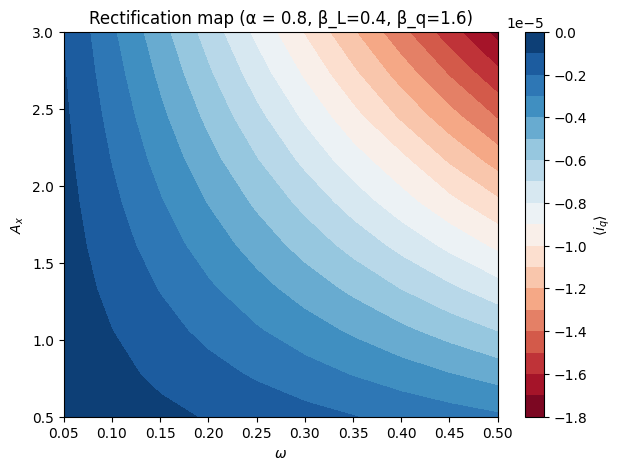


=== alpha = 0.9 ===


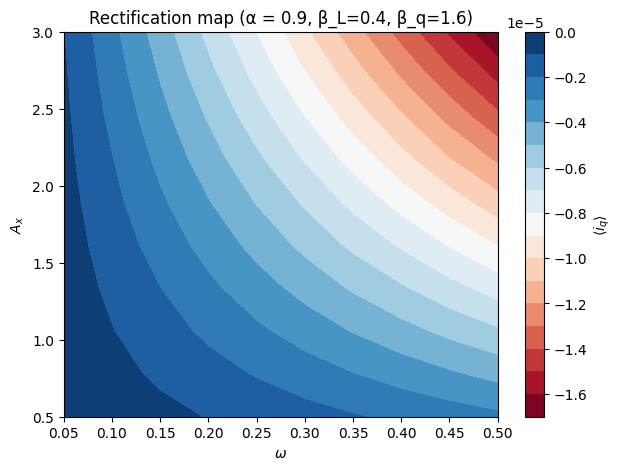


=== alpha = 1.0 ===


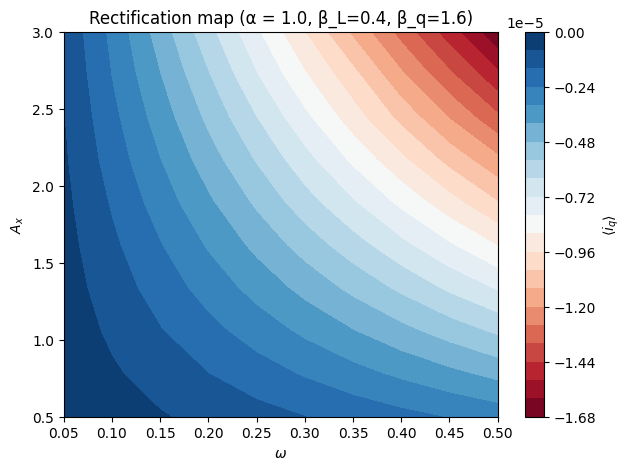


=== alpha = 1.1 ===


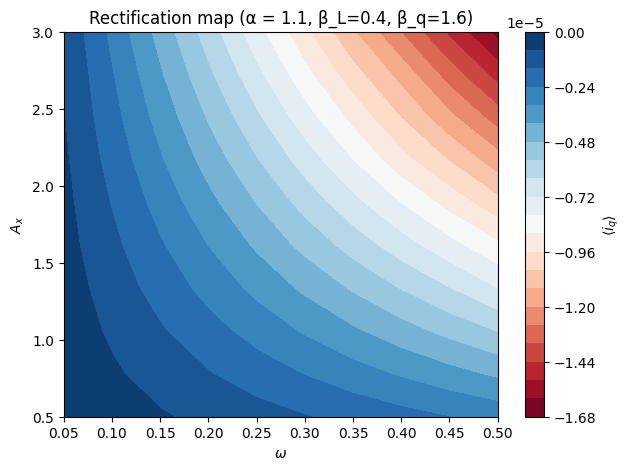


=== alpha = 1.2 ===


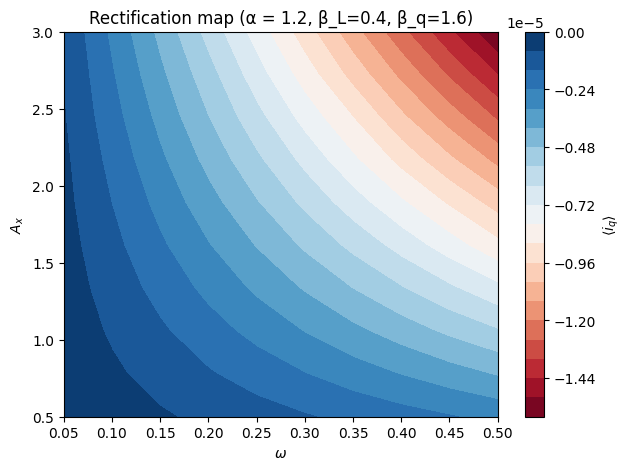


=== Градиентный спуск ===
Iter 0: Ax=1.5000, ω=0.2000, α=1.1000, |<iq>|=0.00000
Градиент стал малым, остановка.

Оптимальные параметры (β_L, β_q, Ax, ω, φ_in, α):
['0.4000', '1.6000', '1.5000', '0.2000', '0.0000', '1.1000']
Максимальное |<iq>| = 0.00000


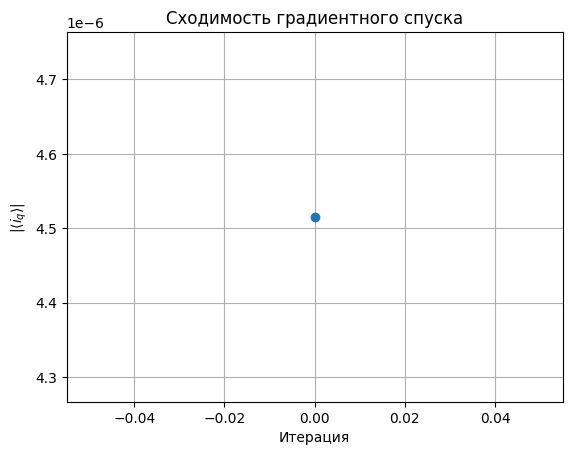

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# =============================================================================
# 1. ФИЗИЧЕСКАЯ МОДЕЛЬ И УРАВНЕНИЯ ДВИЖЕНИЯ
# =============================================================================
#
# Адиабатический квантовый параметрон (AQFP) состоит из двух джозефсоновских
# переходов J1, J2, индуктивностей L1, L2 и центральной индуктивности Lq.
# Управляющий (возбуждающий) ток I_x создаёт в петлях магнитный поток
# через взаимные индуктивности M. Входной ток I_in подаётся в узел Lq.
#
# Фазы на переходах: φ1, φ2.
# Нормированные переменные:
#   φ_x = 2π M I_x / Φ0,   φ_in = 2π Lq I_in / Φ0,
#   β_L = 2π L1 I_c / Φ0,  β_q = 2π Lq I_c / Φ0,
#   где I_c – критический ток перехода J1, J2 (при симметрии).
#
# Потенциальная энергия (при симметрии) дана в статье (1).
# Уравнения Кирхгофа и RCSJ-динамика (β_c = 0) сводятся к системе двух ОДУ:
#
#   dφ1/dt = -sin(φ1) - (φ1 - φ_x)/β_L - (φ1 - φ2 - φ_in)/β_q
#   dφ2/dt = -sin(φ2) - (φ2 + φ_x)/β_L + (φ1 - φ2 - φ_in)/β_q
#
# Время t измеряется в единицах τ_c = Φ0/(2π I_c R), где R – нормальное
# сопротивление перехода (предполагается шунтирование до β_c ≈ 1).
#
# Для возникновения эффекта выпрямления (ненулевого среднего выходного тока)
# при симметричном возбуждении φ_x(t) = A_x sin(ω t) необходимо нарушить
# симметрию схемы. Простейший способ – ввести различие критических токов:
#   I_{c1} = I_c,    I_{c2} = α I_c,   где α ≠ 1.
# Тогда член sin(φ2) домножается на α. Другие варианты: асимметрия
# индуктивностей, постоянное смещение в φ_x.
#
# Выходной ток через центральную индуктивность:
#   i_q = (φ1 - φ2 - φ_in) / β_q.
#
# =============================================================================

def aqfp_rhs(state, t, params):
    """
    Правая часть системы ОДУ для AQFP с возможной асимметрией переходов.

    Параметры:
    state : [phi1, phi2] – фазы на переходах J1 и J2.
    t     : текущее безразмерное время.
    params: кортеж (beta_L, beta_q, Ax, omega, phi_in, alpha),
            где alpha = I_c2 / I_c1 (по умолчанию 1.0).
    Возбуждение: phi_x(t) = Ax * sin(omega * t).
    """
    phi1, phi2 = state
    beta_L, beta_q, Ax, omega, phi_in, alpha = params
    phi_x = Ax * np.sin(omega * t)

    # Уравнения Кирхгофа-Лагранжа с диссипацией (RCSJ, β_c=0)
    dphi1 = -np.sin(phi1) - (phi1 - phi_x)/beta_L - (phi1 - phi2 - phi_in)/beta_q
    dphi2 = -alpha * np.sin(phi2) - (phi2 + phi_x)/beta_L + (phi1 - phi2 - phi_in)/beta_q

    return [dphi1, dphi2]

def output_current(state, params):
    """Вычисление нормированного выходного тока i_q."""
    phi1, phi2 = state
    beta_L, beta_q, Ax, omega, phi_in, alpha = params
    return (phi1 - phi2 - phi_in) / beta_q

# =============================================================================
# 2. ЧИСЛЕННОЕ ИНТЕГРИРОВАНИЕ И ВЫЧИСЛЕНИЕ СРЕДНЕГО
# =============================================================================
def simulate_and_average(params, n_periods=50, n_points_per_period=200,
                         transient_ratio=0.3):
    """
    Интегрирование ОДУ на n_periods периодов возбуждения.
    Возвращает среднее значение i_q по последним (1-transient_ratio)*100% периодам.
    """
    beta_L, beta_q, Ax, omega, phi_in, alpha = params
    T = 2*np.pi / omega
    t_max = n_periods * T
    t_eval = np.linspace(0, t_max, n_periods * n_points_per_period)

    y0 = [0.0, 0.0]
    sol = odeint(aqfp_rhs, y0, t_eval, args=(params,), rtol=1e-6, atol=1e-8)
    phi1_arr, phi2_arr = sol[:, 0], sol[:, 1]

    iq_arr = (phi1_arr - phi2_arr - phi_in) / beta_q

    n_transient = int(transient_ratio * len(t_eval))
    iq_steady = iq_arr[n_transient:]

    return np.mean(iq_steady)

# =============================================================================
# 3. ИССЛЕДОВАНИЕ УСЛОВИЙ ВЫПРЯМЛЕНИЯ (НЕНУЛЕВОГО СРЕДНЕГО)
# =============================================================================
def explore_rectification():
    """
    Сканирование по амплитуде Ax, частоте omega и параметру асимметрии alpha.
    Строит трёхмерную карту (2D срезы) среднего значения i_q.
    """
    # Базовые параметры (адиабатический режим)
    beta_L = 0.4
    beta_q = 1.6
    phi_in = 0.0

    # Диапазоны варьирования
    Ax_vals = np.linspace(0.5, 3.0, 10)
    omega_vals = np.linspace(0.05, 0.5, 10)
    alpha_vals = np.array([0.1, 0.2, 0.5, 0.8, 0.9, 1.0, 1.1, 1.2])   # асимметрия

    # Будем строить отдельный график для каждого alpha
    for alpha in alpha_vals:
        avg_iq = np.zeros((len(Ax_vals), len(omega_vals)))
        print(f"\n=== alpha = {alpha:.1f} ===")
        for i, Ax in enumerate(Ax_vals):
            for j, omega in enumerate(omega_vals):
                params = (beta_L, beta_q, Ax, omega, phi_in, alpha)
                avg_iq[i, j] = simulate_and_average(params, n_periods=60)
                # Печатаем только значимые значения
                if abs(avg_iq[i,j]) > 1e-4:
                    print(f"  Ax={Ax:.2f}, ω={omega:.3f} -> <iq>={avg_iq[i,j]:.4f}")

        # Визуализация
        plt.figure(figsize=(7,5))
        cp = plt.contourf(omega_vals, Ax_vals, avg_iq, levels=20, cmap='RdBu')
        plt.colorbar(cp, label=r'$\langle i_q \rangle$')
        plt.xlabel(r'$\omega$')
        plt.ylabel(r'$A_x$')
        plt.title(f'Rectification map (α = {alpha}, β_L={beta_L}, β_q={beta_q})')
        plt.show()

# =============================================================================
# 4. ГРАДИЕНТНЫЙ СПУСК ДЛЯ МАКСИМИЗАЦИИ |<iq>|
# =============================================================================
def gradient_descent_maximize(init_params, lr=0.05, delta=0.1, max_iter=30,
                              tol=1e-4, verbose=True):
    """
    Градиентный спуск с конечными разностями.
    Варьируемые параметры (индексы в params): Ax (2), omega (3), alpha (5).
    beta_L, beta_q, phi_in фиксированы.
    Минимизирует -|<iq>|, что эквивалентно максимизации |<iq>|.
    """
    params = np.array(init_params, dtype=float)
    # Фиксируем индексы не варьируемых параметров
    fixed_mask = [True, True, False, False, True, False]  # beta_L, beta_q, Ax, omega, phi_in, alpha
    # Для удобства создадим маску варьируемых и их индексы
    var_indices = [2, 3, 5]
    var_labels = ['Ax', 'omega', 'alpha']

    def objective(var_values):
        # var_values – список значений варьируемых параметров в порядке [Ax, omega, alpha]
        p = params.copy()
        p[2] = var_values[0]
        p[3] = var_values[1]
        p[5] = var_values[2]
        return -abs(simulate_and_average(tuple(p), n_periods=40))

    history = []
    for it in range(max_iter):
        current_var = np.array([params[2], params[3], params[5]])
        val = objective(current_var)
        history.append(-val)

        # Оценка градиента конечными разностями
        grad = np.zeros(3)
        for i in range(3):
            perturb = np.zeros(3)
            perturb[i] = delta
            f_plus = objective(current_var + perturb)
            f_minus = objective(current_var - perturb)
            grad[i] = (f_plus - f_minus) / (2*delta)

        # Обновление
        new_var = current_var - lr * grad

        # Ограничения: Ax > 0.1, omega > 0.01, alpha > 0.1
        new_var[0] = max(0.1, new_var[0])
        new_var[1] = max(0.01, new_var[1])
        new_var[2] = max(0.1, new_var[2])   # alpha должно быть положительным

        params[2] = new_var[0]
        params[3] = new_var[1]
        params[5] = new_var[2]

        if verbose:
            print(f"Iter {it}: Ax={params[2]:.4f}, ω={params[3]:.4f}, α={params[5]:.4f}, "
                  f"|<iq>|={-val:.5f}")

        if np.linalg.norm(grad) < tol:
            if verbose:
                print("Градиент стал малым, остановка.")
            break

    return params, history

# =============================================================================
# 5. ДЕМОНСТРАЦИЯ
# =============================================================================
if __name__ == "__main__":
    # 5.1 Исследование карт выпрямления при разных α
    print("=== Исследование условий выпрямления ===")
    explore_rectification()

    # 5.2 Оптимизация градиентным спуском
    # Выберем начальные параметры, при которых среднее заведомо не ноль.
    # Из анализа карт (при alpha=1.1, например) можно взять Ax=1.5, omega=0.2.
    print("\n=== Градиентный спуск ===")
    initial_params = [0.4, 1.6, 1.5, 0.2, 0.0, 1.1]  # beta_L, beta_q, Ax, omega, phi_in, alpha
    opt_params, hist = gradient_descent_maximize(initial_params, lr=0.05, delta=0.1,
                                                 max_iter=20, tol=1e-4)

    print("\nОптимальные параметры (β_L, β_q, Ax, ω, φ_in, α):")
    print([f"{p:.4f}" for p in opt_params])
    print(f"Максимальное |<iq>| = {hist[-1]:.5f}")

    # График сходимости
    plt.figure()
    plt.plot(hist, 'o-')
    plt.xlabel('Итерация')
    plt.ylabel(r'$|\langle i_q \rangle|$')
    plt.title('Сходимость градиентного спуска')
    plt.grid(True)
    plt.show()